# Geometric Comparison of Word Mover's Distance on STS-B

**Author:** Morchid Saad — INSEA — 3D Smart Factory

**Project:** Geometry-Aware Optimal Transport for Interpretable Semantic Textual Similarity (PFE)

## Abstract

This notebook evaluates how the choice of geometric space affects Word Mover's Distance (WMD) for sentence similarity. We compare three cost functions — Euclidean, spherical (angular), and hyperbolic (Poincaré) — applied to the same GloVe 300d word vectors, with identical preprocessing, weighting, and transport solver. The only variable that changes across conditions is the distance function inside the cost matrix. By holding every other component constant, the notebook isolates the effect of cost-function geometry on sentence similarity — the core research question of this project.

A cosine-of-mean baseline (no transport) contextualizes whether optimal transport adds value beyond simple averaging.

This is the first notebook in the experimental pipeline. The HyperLex diagnostic notebook investigates natively trained hyperbolic embeddings at the word level; the native hyperbolic WMD notebook tests them on STS-B.

## Notebook structure

| Section | Content |
|---|---|
| 1 | Setup — imports, configuration, reproducibility seeds |
| 2 | Data loading — GloVe 300d, STS-B, stop words, lemmatizer |
| 3 | Shared pipeline — tokenization, TF-IDF weighting |
| 4 | Three projections — raw, normalized, exponential map |
| 5 | Three cost functions — Euclidean, spherical, Poincaré |
| 6 | Cosine baseline — mean-vector similarity |
| 7 | WMD evaluation — all three geometries on STS-B validation |
| 8 | Results — comparison table, scatter plots |
| 9 | Transport plan visualization — example pair, three heatmaps |
| 10 | Per-pair analysis — which geometry wins which pairs |
| 11 | Hierarchy-rich subset — filtered STS-B evaluation |
| 12 | Summary — final table and conclusions |

## 1. Setup

Standard imports, configuration constants, and random seeds for reproducibility.

In [1]:
# Standard library
import os
import math
import random
from pathlib import Path
from collections import Counter

# Scientific stack
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr, pearsonr
from tqdm import tqdm
import ot

# NLP
import nltk
nltk.download("stopwords", quiet=True)
nltk.download("wordnet", quiet=True)
from nltk.corpus import stopwords, wordnet as wn
from nltk.stem import WordNetLemmatizer

# Embeddings + data
import gensim.downloader as api
from datasets import load_dataset

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Plot styling
sns.set_theme(style="whitegrid", context="paper", font_scale=1.1)
plt.rcParams["figure.dpi"] = 100
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["savefig.bbox"] = "tight"

print("Imports OK")

Imports OK


In [2]:
# ---- Configuration --------------------------------------------------------
BASE_DIR = Path.cwd()
FIGURES_DIR = BASE_DIR / "figures" / "wmd_geometric_comparison"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# NLP resources
STOP_WORDS = set(stopwords.words("english"))
LEMMATIZER = WordNetLemmatizer()

print(f"Working directory: {BASE_DIR}")
print(f"Stop words: {len(STOP_WORDS)}")

Working directory: /home/saad1/pfe
Stop words: 198


## 2. Data loading

We load three resources:
- **GloVe 300d** word vectors (400k vocabulary, trained on Wikipedia + Gigaword)
- **STS-B** benchmark from the GLUE suite (train for IDF computation, validation for evaluation)
- **NLTK** stop words and WordNet lemmatizer

In [3]:
# Load GloVe 300d
print("Loading GloVe 300d...")
MODEL = api.load("glove-wiki-gigaword-300")
print(f"  {len(MODEL.key_to_index):,} words, {MODEL.vector_size}d")

# Load STS-B
print("Loading STS-B...")
stsb = load_dataset("nyu-mll/glue", "stsb")
print(f"  Train: {len(stsb['train']):,} | Validation: {len(stsb['validation']):,}")

# Quick stats
all_norms = np.array([np.linalg.norm(MODEL[w]) for w in list(MODEL.key_to_index.keys())[:50000]])
print(f"\nGloVe norm statistics (sampled 50k words):")
print(f"  Mean: {all_norms.mean():.3f}")
print(f"  Std:  {all_norms.std():.3f}")
print(f"  Min:  {all_norms.min():.3f}")
print(f"  Max:  {all_norms.max():.3f}")

Loading GloVe 300d...
  400,000 words, 300d
Loading STS-B...


  Train: 5,749 | Validation: 1,500

GloVe norm statistics (sampled 50k words):
  Mean: 6.690
  Std:  0.931
  Min:  2.610
  Max:  17.168


## 3. Shared pipeline

Tokenization, lemmatization, and TF-IDF weighting are identical across all three geometric conditions. IDF is computed on the STS-B training set to avoid data leakage.

In [4]:
# ---- Tokenization ---------------------------------------------------------
def tokenize(text):
    """
    Tokenize, remove punctuation and stop words, lemmatize,
    filter to words present in GloVe vocabulary.
    Returns (known_words, unknown_words).
    """
    for ch in ".,!?;:\"'()[]{}—–-/":
        text = text.replace(ch, " ")
    known, unknown = [], []
    for w in text.lower().split():
        if w in STOP_WORDS or len(w) < 2:
            continue
        w = LEMMATIZER.lemmatize(w)
        if w in MODEL.key_to_index:
            known.append(w)
        else:
            unknown.append(w)
    return known, unknown


# ---- IDF from STS-B train ------------------------------------------------
def build_idf(dataset):
    """IDF(w) = log(N / (1 + df(w))) computed on both sentences of each pair."""
    docs = []
    for ex in dataset:
        docs.append(tokenize(ex["sentence1"])[0])
        docs.append(tokenize(ex["sentence2"])[0])
    N = len(docs)
    df = Counter()
    for doc in docs:
        for w in set(doc):
            df[w] += 1
    return {w: math.log(N / (1 + f)) for w, f in df.items()}


print("Computing IDF on STS-B train...")
IDF = build_idf(stsb["train"])
IDF_DEFAULT = math.log(len(stsb["train"]) * 2)
print(f"  IDF computed for {len(IDF):,} words")


# ---- TF-IDF weighting ----------------------------------------------------
def compute_weights(tokens):
    """
    TF-IDF weights per unique word, normalized to sum to 1.
    Returns (unique_words, weights_array).
    """
    if not tokens:
        return [], np.array([])
    counts = Counter(tokens)
    total = len(tokens)
    words, weights = [], []
    for w, cnt in counts.items():
        tf = cnt / total
        idf = IDF.get(w, IDF_DEFAULT)
        words.append(w)
        weights.append(tf * idf)
    weights = np.array(weights, dtype=np.float64)
    weights /= weights.sum()
    order = np.argsort(-weights)
    words = [words[i] for i in order]
    weights = weights[order]
    return words, weights


print("Pipeline ready.")

Computing IDF on STS-B train...
  IDF computed for 9,780 words
Pipeline ready.


## 4. Three projections

Each geometry requires a specific transformation of the raw GloVe vectors:

| Condition | Transformation | Rationale |
|---|---|---|
| Euclidean | None (raw GloVe) | Flat-geometry baseline |
| Spherical | L2-normalize: `v / ‖v‖` | Projects onto the unit sphere; cosine similarity becomes angular distance |
| Hyperbolic | Exponential map: `tanh(‖v‖/c) · v/‖v‖` | Maps into the Poincaré ball; typical word at radius tanh(1) ≈ 0.76, avoiding boundary saturation |

For the hyperbolic projection, `c = mean(‖GloVe‖)` over the vocabulary. This is a data-derived calibration — not a task-tuned hyperparameter.

In [5]:
# ---- Compute calibration constant ----------------------------------------
print("Computing calibration constant c = mean(||GloVe||) ...")
all_words = list(MODEL.key_to_index.keys())
sample_norms = np.array([np.linalg.norm(MODEL[w]) for w in all_words[:100000]])
C_CALIBRATION = float(sample_norms.mean())
print(f"  c = {C_CALIBRATION:.4f} (mean norm over 100k words)")
print(f"  tanh(1) = {np.tanh(1.0):.4f} → typical word radius in Poincaré ball")


# ---- Projection functions ------------------------------------------------
def project_euclidean(word):
    """Raw GloVe vector — no transformation."""
    return MODEL[word]


def project_spherical(word):
    """L2-normalized GloVe vector — lives on the unit sphere."""
    v = MODEL[word]
    return v / np.linalg.norm(v)


def project_hyperbolic(word, c=None):
    """
    Exponential map at the origin of the Poincaré ball.
    v_hyp = tanh(||v|| / c) * v / ||v||
    where c = mean(||GloVe||) over the vocabulary.
    """
    if c is None:
        c = C_CALIBRATION
    v = MODEL[word]
    norm = np.linalg.norm(v)
    if norm < 1e-10:
        return v * 0.0
    r = float(np.tanh(norm / c))
    return r * v / norm


# ---- Verify projections on sample words ----------------------------------
test_words = ["the", "dog", "poodle", "entity", "saxophone"]
print(f"\n{'Word':<15} {'GloVe norm':>12} {'Spherical':>12} {'Hyperbolic r':>14}")
print("-" * 55)
for w in test_words:
    if w in MODEL.key_to_index:
        gn = np.linalg.norm(MODEL[w])
        sn = np.linalg.norm(project_spherical(w))
        hn = np.linalg.norm(project_hyperbolic(w))
        print(f"{w:<15} {gn:>12.4f} {sn:>12.4f} {hn:>14.4f}")

# ---- Sample norms for projection distribution plot ----------------------
print("\nSampling 10k words for norm distribution plot...")
sample_10k = list(MODEL.key_to_index.keys())[:10000]
norms_euc = np.array([np.linalg.norm(MODEL[w]) for w in sample_10k])
norms_hyp = np.array([np.linalg.norm(project_hyperbolic(w)) for w in sample_10k])
print(f"  Sampled {len(sample_10k)} words")

Computing calibration constant c = mean(||GloVe||) ...
  c = 6.8640 (mean norm over 100k words)
  tanh(1) = 0.7616 → typical word radius in Poincaré ball

Word              GloVe norm    Spherical   Hyperbolic r
-------------------------------------------------------
the                   5.1814       1.0000         0.6380
dog                   6.6731       1.0000         0.7497
poodle                6.6431       1.0000         0.7477
entity                6.3300       1.0000         0.7269
saxophone             6.7754       1.0000         0.7561

Sampling 10k words for norm distribution plot...
  Sampled 10000 words


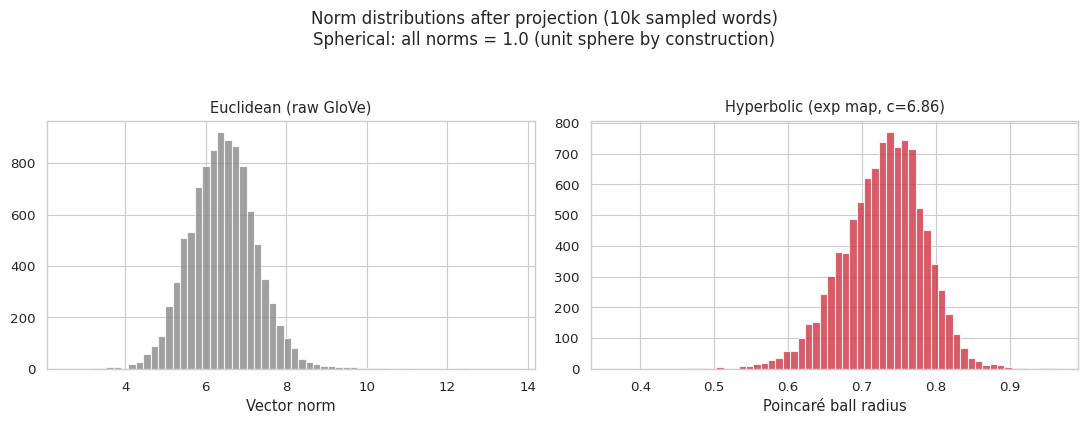

Hyperbolic radius range: [0.3629, 0.9628]


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(norms_euc, bins=60, color="#888888", edgecolor="white", alpha=0.8)
axes[0].set_title("Euclidean (raw GloVe)")
axes[0].set_xlabel("Vector norm")

axes[1].hist(norms_hyp, bins=60, color="#CC3344", edgecolor="white", alpha=0.8)
axes[1].set_title(f"Hyperbolic (exp map, c={C_CALIBRATION:.2f})")
axes[1].set_xlabel("Poincaré ball radius")

plt.suptitle("Norm distributions after projection (10k sampled words)\nSpherical: all norms = 1.0 (unit sphere by construction)",
             fontsize=12, y=1.05)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "projection_norm_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"Hyperbolic radius range: [{min(norms_hyp):.4f}, {max(norms_hyp):.4f}]")

## 5. Three cost functions

The cost matrix `C[i,j]` measures the distance between word `i` in sentence A and word `j` in sentence B. The three conditions differ only in this function:

| Condition | Cost function | Formula |
|---|---|---|
| Euclidean | L2 distance | `‖u − v‖` |
| Spherical | Arc distance | `arccos(cos_sim(u, v))` |
| Hyperbolic | Poincaré distance | `arccosh(1 + 2‖u−v‖² / ((1−‖u‖²)(1−‖v‖²)))` |

In [7]:
# ---- Cost functions -------------------------------------------------------
def cost_euclidean(words_a, words_b):
    """Euclidean distance between raw GloVe vectors."""
    vecs_a = np.array([project_euclidean(w) for w in words_a])
    vecs_b = np.array([project_euclidean(w) for w in words_b])
    sq_a = np.sum(vecs_a ** 2, axis=1, keepdims=True)
    sq_b = np.sum(vecs_b ** 2, axis=1, keepdims=True)
    C = np.sqrt(np.maximum(sq_a + sq_b.T - 2 * vecs_a @ vecs_b.T, 0.0))
    return C


def cost_spherical(words_a, words_b):
    """Arc distance on the unit sphere: arccos(cos_sim(u, v))."""
    vecs_a = np.array([project_spherical(w) for w in words_a])
    vecs_b = np.array([project_spherical(w) for w in words_b])
    # Vectors are unit-norm, so dot product = cosine similarity
    cos_sim = vecs_a @ vecs_b.T
    cos_sim = np.clip(cos_sim, -1.0, 1.0)  # numerical safety
    return np.arccos(cos_sim)


def cost_poincare(words_a, words_b):
    """
    Poincaré ball distance
    standard Poincaré distance: d(u, v) = arccosh(1 + 2‖u−v‖² / ((1−‖u‖²)(1−‖v‖²)))
    """
    vecs_a = np.array([project_hyperbolic(w) for w in words_a])
    vecs_b = np.array([project_hyperbolic(w) for w in words_b])

    norm_a_sq = np.sum(vecs_a ** 2, axis=1, keepdims=True)  # (n, 1)
    norm_b_sq = np.sum(vecs_b ** 2, axis=1, keepdims=True)  # (m, 1)

    # ||u - v||^2 via expansion
    diff_sq = norm_a_sq + norm_b_sq.T - 2 * vecs_a @ vecs_b.T  # (n, m)
    diff_sq = np.maximum(diff_sq, 0.0)

    denom = (1 - norm_a_sq) * (1 - norm_b_sq.T)  # (n, m)
    denom = np.maximum(denom, 1e-10)

    arg = 1 + 2 * diff_sq / denom
    arg = np.maximum(arg, 1.0)  # arccosh domain

    return np.arccosh(arg)


# Sanity check
test_a = ["dog", "cat"]
test_b = ["animal", "vehicle"]
print("Cost matrices for ['dog', 'cat'] vs ['animal', 'vehicle']:\n")
for name, fn in [("Euclidean", cost_euclidean), ("Spherical", cost_spherical), ("Poincaré", cost_poincare)]:
    C = fn(test_a, test_b)
    print(f"{name}:")
    for i, wa in enumerate(test_a):
        for j, wb in enumerate(test_b):
            print(f"  {wa:>6} → {wb:<10} {C[i,j]:.4f}")
    print()

Cost matrices for ['dog', 'cat'] vs ['animal', 'vehicle']:

Euclidean:
     dog → animal     6.4064
     dog → vehicle    8.2893
     cat → animal     6.8157
     cat → vehicle    8.8220

Spherical:
     dog → animal     1.0103
     dog → vehicle    1.3330
     cat → animal     1.1137
     cat → vehicle    1.4821

Poincaré:
     dog → animal     2.5289
     dog → vehicle    3.0058
     cat → animal     2.5896
     cat → vehicle    3.0702



## 6. WMD computation and cosine baseline

The WMD function solves the exact Earth Mover's Distance using POT, given a cost matrix and TF-IDF weights. The cosine baseline computes cosine similarity between mean GloVe sentence vectors — no transport, no alignment.

In [8]:
# ---- WMD (exact EMD via POT) ----------------------------------------------
def wmd(text_a, text_b, cost_fn):
    """
    Compute exact WMD between two texts using the given cost function.
    Returns dict with score and transport details, or inf on failure.
    """
    tokens_a, _ = tokenize(text_a)
    tokens_b, _ = tokenize(text_b)
    words_a, weights_a = compute_weights(tokens_a)
    words_b, weights_b = compute_weights(tokens_b)

    if len(words_a) == 0 or len(words_b) == 0:
        return {"score": float("inf"), "error": "No known words"}

    C = cost_fn(words_a, words_b)

    # Strict normalization for POT
    wa = weights_a / weights_a.sum()
    wb = weights_b / weights_b.sum()

    T = ot.emd(wa, wb, C)
    cost = float(np.sum(T * C))

    return {
        "score": cost,
        "T": T,
        "words_a": words_a,
        "words_b": words_b,
        "weights_a": wa,
        "weights_b": wb,
        "C": C,
    }


# ---- Cosine baseline (no transport) --------------------------------------
def cosine_baseline(text_a, text_b):
    """
    Cosine similarity between TF-IDF-weighted mean GloVe vectors.
    No transport, no alignment — just averaged representations.
    """
    tokens_a, _ = tokenize(text_a)
    tokens_b, _ = tokenize(text_b)
    words_a, weights_a = compute_weights(tokens_a)
    words_b, weights_b = compute_weights(tokens_b)

    if len(words_a) == 0 or len(words_b) == 0:
        return float("nan")
        
    # Uses raw GloVe vectors; normalization is implicit in the final cosine computation
    vecs_a = np.array([MODEL[w] for w in words_a])
    vecs_b = np.array([MODEL[w] for w in words_b])

    mean_a = weights_a @ vecs_a
    mean_b = weights_b @ vecs_b

    cos_sim = np.dot(mean_a, mean_b) / (np.linalg.norm(mean_a) * np.linalg.norm(mean_b) + 1e-10)
    return float(cos_sim)


print("WMD and cosine baseline functions ready.")

WMD and cosine baseline functions ready.


## 7. WMD evaluation — all three geometries

We evaluate all three WMD conditions and the cosine baseline on the STS-B validation set. WMD scores are distances (lower = more similar), while cosine scores are similarities (higher = more similar). Both are compared to human ratings via Spearman and Pearson correlation.

In [9]:
# ---- Evaluate all conditions ----------------------------------------------
def evaluate_wmd(dataset, cost_fn, label):
    """Evaluate WMD with a given cost function on all pairs. Returns per-pair scores."""
    scores, labels, pair_indices = [], [], []
    failed = 0

    print(f"  Evaluating {label}...")
    for idx, ex in enumerate(tqdm(dataset, desc=f"    {label}")):
        res = wmd(ex["sentence1"], ex["sentence2"], cost_fn)
        if res["score"] == float("inf"):
            failed += 1
            continue
        scores.append(res["score"])
        labels.append(ex["label"])
        pair_indices.append(idx)

    scores = np.array(scores)
    labels = np.array(labels)

    # WMD is a distance — negate for correlation (lower distance = higher similarity)
    rho, p_rho = spearmanr(-scores, labels)
    r, p_r = pearsonr(-scores, labels)

    print(f"    Spearman: {rho:.4f} (p={p_rho:.2e}) | Pearson: {r:.4f} (p={p_r:.2e})")
    print(f"    Pairs: {len(scores)} | Failed: {failed}")

    return {
        "label": label, "scores": scores, "labels": labels,
        "pair_indices": pair_indices,
        "spearman": rho, "spearman_pval": p_rho,
        "pearson": r, "pearson_pval": p_r,
        "failed": failed,
    }


def evaluate_cosine(dataset):
    """Evaluate cosine baseline on all pairs."""
    scores, labels = [], []
    failed = 0

    print("  Evaluating Cosine baseline...")
    for ex in tqdm(dataset, desc="    Cosine"):
        s = cosine_baseline(ex["sentence1"], ex["sentence2"])
        if np.isnan(s):
            failed += 1
            continue
        scores.append(s)
        labels.append(ex["label"])

    scores = np.array(scores)
    labels = np.array(labels)

    # Cosine is a similarity — no negation needed
    rho, p_rho = spearmanr(scores, labels)
    r, p_r = pearsonr(scores, labels)

    print(f"    Spearman: {rho:.4f} (p={p_rho:.2e}) | Pearson: {r:.4f} (p={p_r:.2e})")

    return {
        "label": "Cosine baseline", "scores": scores, "labels": labels,
        "spearman": rho, "spearman_pval": p_rho,
        "pearson": r, "pearson_pval": p_r,
        "failed": failed,
    }


# ---- Run all evaluations -------------------------------------------------
print("=" * 60)
print(" EVALUATION ON STS-B VALIDATION")
print("=" * 60)
print()

results_cosine = evaluate_cosine(stsb["validation"])
results_euclidean = evaluate_wmd(stsb["validation"], cost_euclidean, "Euclidean WMD")
results_spherical = evaluate_wmd(stsb["validation"], cost_spherical, "Spherical WMD")
results_hyperbolic = evaluate_wmd(stsb["validation"], cost_poincare, "Hyperbolic WMD")

print("\nAll evaluations complete.")

 EVALUATION ON STS-B VALIDATION

  Evaluating Cosine baseline...


    Cosine: 100%|█████████████████████████████████████████████████████████████████| 1500/1500 [00:00<00:00, 4115.49it/s]


    Spearman: 0.7389 (p=3.99e-259) | Pearson: 0.7255 (p=2.46e-245)
  Evaluating Euclidean WMD...


    Euclidean WMD: 100%|██████████████████████████████████████████████████████████| 1500/1500 [00:00<00:00, 2287.42it/s]


    Spearman: 0.7768 (p=4.00e-303) | Pearson: 0.7736 (p=4.33e-299)
    Pairs: 1500 | Failed: 0
  Evaluating Spherical WMD...


    Spherical WMD: 100%|██████████████████████████████████████████████████████████| 1500/1500 [00:00<00:00, 2240.00it/s]


    Spearman: 0.7748 (p=1.36e-300) | Pearson: 0.7728 (p=4.35e-298)
    Pairs: 1500 | Failed: 0
  Evaluating Hyperbolic WMD...


    Hyperbolic WMD: 100%|█████████████████████████████████████████████████████████| 1500/1500 [00:00<00:00, 1764.65it/s]

    Spearman: 0.7744 (p=3.84e-300) | Pearson: 0.7697 (p=2.78e-294)
    Pairs: 1500 | Failed: 0

All evaluations complete.


## 8. Results — comparison table and scatter plots

In [10]:
# ---- Comparison table -----------------------------------------------------
all_results = [results_cosine, results_euclidean, results_spherical, results_hyperbolic]

results_df = pd.DataFrame([{
    "Method": r["label"],
    "Spearman ρ": r["spearman"],
    "Pearson r": r["pearson"],
    "Failed pairs": r["failed"],
} for r in all_results])

print(results_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

results_df.to_csv(FIGURES_DIR / "geometric_comparison_results.csv", index=False)
print(f"\nSaved to {FIGURES_DIR / 'geometric_comparison_results.csv'}")

         Method  Spearman ρ  Pearson r  Failed pairs
Cosine baseline      0.7389     0.7255             0
  Euclidean WMD      0.7768     0.7736             0
  Spherical WMD      0.7748     0.7728             0
 Hyperbolic WMD      0.7744     0.7697             0

Saved to /home/saad1/pfe/figures/wmd_geometric_comparison/geometric_comparison_results.csv


All three WMD geometries perform within 0.002 Spearman ρ of each other (Euclidean 0.777, Spherical 0.775, Hyperbolic 0.774). The choice of cost-function geometry has negligible impact on sentence similarity when the underlying embeddings are Euclidean-trained and the benchmark is paraphrastic.

WMD consistently outperforms the cosine-of-mean baseline (ρ = 0.739) by roughly +0.036 across all geometries, confirming that word-level optimal transport captures alignment structure that simple averaging misses — and justifying the computational cost of exact EMD.

The scatter plots below visualize the score-vs-rating relationship for each WMD condition.

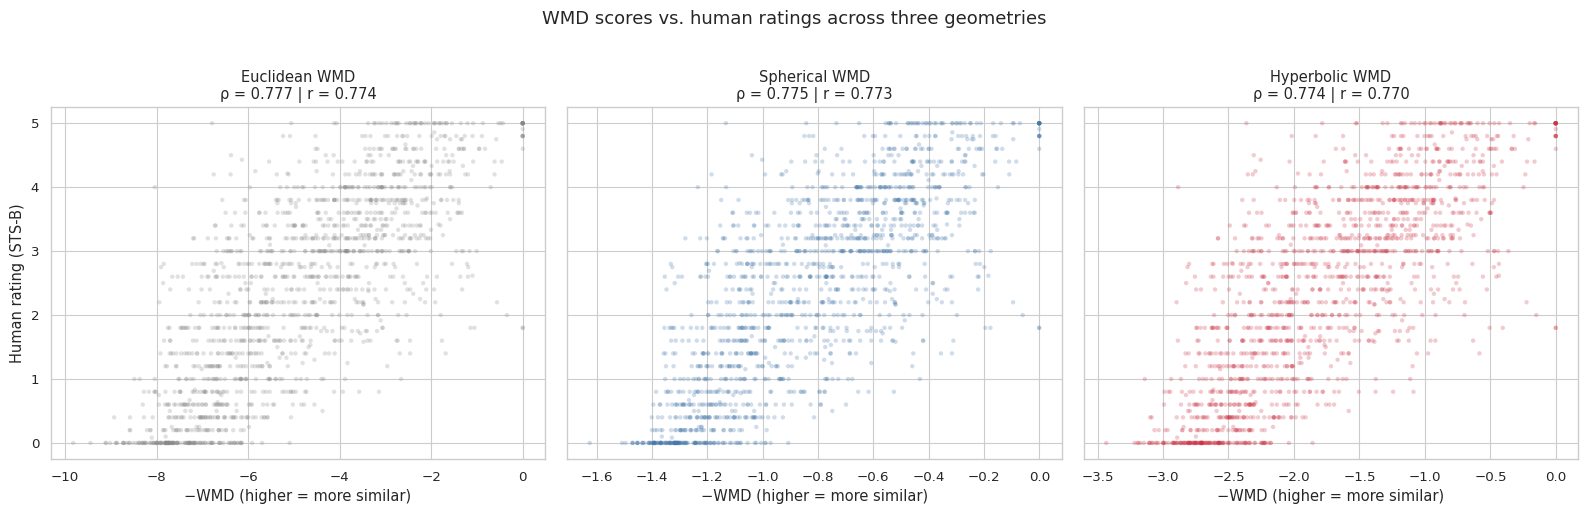

In [11]:
# ---- Scatter plots: WMD scores vs human ratings --------------------------
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

wmd_results = [results_euclidean, results_spherical, results_hyperbolic]
colors = ["#888888", "#4477AA", "#CC3344"]

for ax, res, color in zip(axes, wmd_results, colors):
    # Negate WMD scores so higher = more similar (matching human scale direction)
    ax.scatter(-res["scores"], res["labels"], alpha=0.25, s=10, color=color,
               edgecolors="none")
    ax.set_xlabel("−WMD (higher = more similar)")
    ax.set_title(f"{res['label']}\nρ = {res['spearman']:.3f} | r = {res['pearson']:.3f}")

axes[0].set_ylabel("Human rating (STS-B)")

plt.suptitle("WMD scores vs. human ratings across three geometries",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "wmd_scores_vs_human_scatter.png", dpi=300, bbox_inches="tight")
plt.show()

## 9. Transport plan visualization

We visualize the transport plan (matrix T) under all three geometries on a manually selected sentence pair. The pair was chosen to contain cross-sentence near-synonyms (president/leader, speech/talk, growth/development) and semantic alignments that the transport plan should capture clearly, making the heatmaps interpretable. The three heatmaps show how each geometry routes mass between words — revealing which word alignments each distance function favors.

Sentence A: The president delivered a speech about economic growth and job creation.
Sentence B: The leader gave a talk on financial development and employment opportunities.



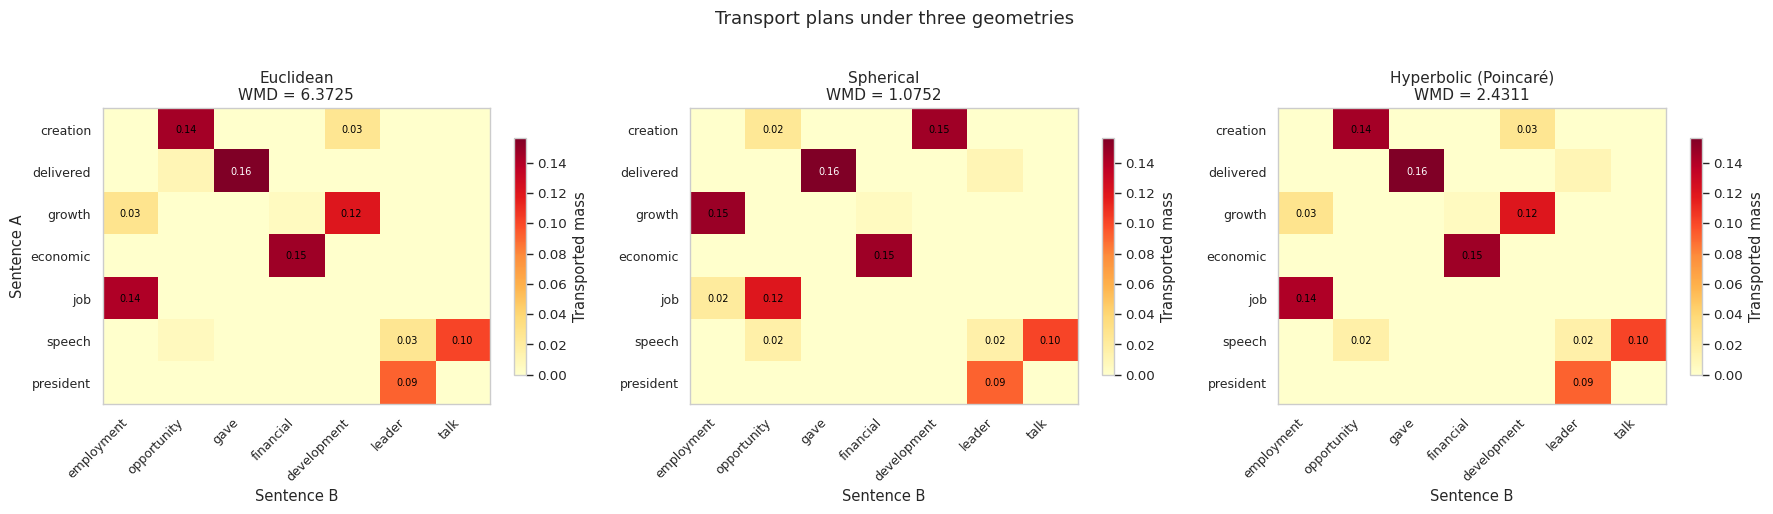

In [12]:
# ---- Example pair for transport visualization ----------------------------
text_a = "The president delivered a speech about economic growth and job creation."
text_b = "The leader gave a talk on financial development and employment opportunities."

print(f"Sentence A: {text_a}")
print(f"Sentence B: {text_b}")
print()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

cost_fns = [
    ("Euclidean", cost_euclidean),
    ("Spherical", cost_spherical),
    ("Hyperbolic (Poincaré)", cost_poincare),
]

for ax, (name, cost_fn) in zip(axes, cost_fns):
    res = wmd(text_a, text_b, cost_fn)
    if "error" in res:
        ax.set_title(f"{name}: failed")
        continue

    im = ax.imshow(res["T"], cmap="YlOrRd", aspect="auto")

    ax.set_xticks(range(len(res["words_b"])))
    ax.set_xticklabels(res["words_b"], rotation=45, ha="right", fontsize=9)
    ax.set_yticks(range(len(res["words_a"])))
    ax.set_yticklabels(res["words_a"], fontsize=9)

    ax.set_title(f"{name}\nWMD = {res['score']:.4f}", fontsize=11)
    ax.set_xlabel("Sentence B")

    ax.grid(False)

    # Annotate significant transport flows
    for i in range(len(res["words_a"])):
        for j in range(len(res["words_b"])):
            val = res["T"][i, j]
            if val > 0.01:
                ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                        fontsize=7, color="black" if val < 0.15 else "white")

    plt.colorbar(im, ax=ax, label="Transported mass", shrink=0.8)

axes[0].set_ylabel("Sentence A")

plt.suptitle("Transport plans under three geometries", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "transport_heatmaps.png", dpi=300, bbox_inches="tight")
plt.show()

## 10. Per-pair analysis

We compare all three geometries at the individual pair level. For each method, we rank all 1,500 pairs by WMD score (ascending, since lower WMD = more similar) and separately rank them by human rating (descending). The per-pair rank error is |method_rank − human_rank|: how far off the method's ranking of that pair is from the human ranking. The geometry with the lowest rank error "wins" that pair. This complements the aggregate Spearman analysis with a pair-level view of where each geometry performs best.

In [13]:
# ---- Per-pair comparison --------------------------------------------------
# Align pairs across all three geometries
common_indices = set(results_euclidean["pair_indices"]) & \
                 set(results_spherical["pair_indices"]) & \
                 set(results_hyperbolic["pair_indices"])

common_indices = sorted(common_indices)  # deterministic iteration order

# Build index maps: pair_index → position in scores array
euc_map = {idx: pos for pos, idx in enumerate(results_euclidean["pair_indices"])}
sph_map = {idx: pos for pos, idx in enumerate(results_spherical["pair_indices"])}
hyp_map = {idx: pos for pos, idx in enumerate(results_hyperbolic["pair_indices"])}

val_data = list(stsb["validation"])
euc_scores = np.array([results_euclidean["scores"][euc_map[i]] for i in common_indices])
sph_scores = np.array([results_spherical["scores"][sph_map[i]] for i in common_indices])
hyp_scores = np.array([results_hyperbolic["scores"][hyp_map[i]] for i in common_indices])
human_labels = np.array([results_euclidean["labels"][euc_map[i]] for i in common_indices])
pair_texts = [(val_data[i]["sentence1"], val_data[i]["sentence2"]) for i in common_indices]

print(f"Aligned pairs: {len(euc_scores)}")

# Per-pair absolute error (lower = better prediction)
euc_ranks = np.argsort(np.argsort(euc_scores))
sph_ranks = np.argsort(np.argsort(sph_scores))
hyp_ranks = np.argsort(np.argsort(hyp_scores))
human_ranks = np.argsort(np.argsort(-human_labels))

euc_err = np.abs(euc_ranks - human_ranks)
sph_err = np.abs(sph_ranks - human_ranks)
hyp_err = np.abs(hyp_ranks - human_ranks)

# Which geometry wins each pair
euc_wins = np.sum((euc_err < sph_err) & (euc_err < hyp_err))
sph_wins = np.sum((sph_err < euc_err) & (sph_err < hyp_err))
hyp_wins = np.sum((hyp_err < euc_err) & (hyp_err < sph_err))
ties = len(euc_err) - euc_wins - sph_wins - hyp_wins

print(f"\nPer-pair wins (by rank error):")
print(f"  Euclidean:  {euc_wins} ({100*euc_wins/len(euc_err):.1f}%)")
print(f"  Spherical:  {sph_wins} ({100*sph_wins/len(euc_err):.1f}%)")
print(f"  Hyperbolic: {hyp_wins} ({100*hyp_wins/len(euc_err):.1f}%)")
print(f"  Ties:       {ties} ({100*ties/len(euc_err):.1f}%)")

Aligned pairs: 1500

Per-pair wins (by rank error):
  Euclidean:  273 (18.2%)
  Spherical:  654 (43.6%)
  Hyperbolic: 539 (35.9%)
  Ties:       34 (2.3%)


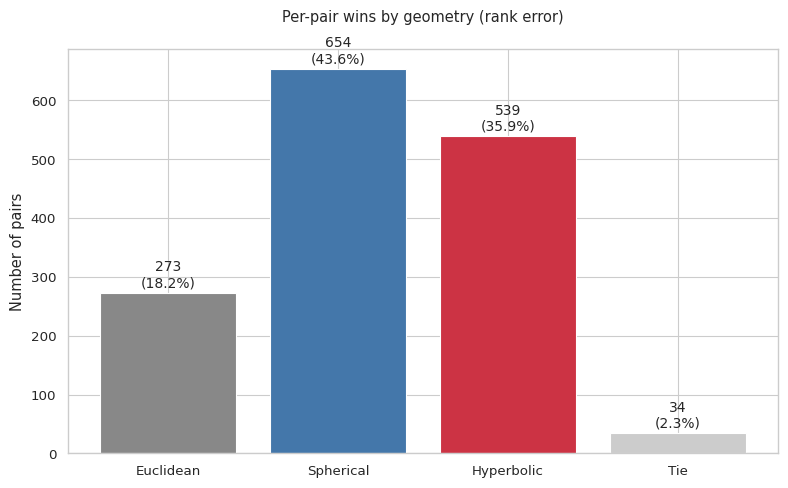

In [14]:
# ---- Visualize per-pair wins ----------------------------------------------
fig, ax = plt.subplots(figsize=(8, 5))
categories = ["Euclidean", "Spherical", "Hyperbolic", "Tie"]
counts = [euc_wins, sph_wins, hyp_wins, ties]
bar_colors = ["#888888", "#4477AA", "#CC3344", "#CCCCCC"]

ax.bar(categories, counts, color=bar_colors, edgecolor="white")
for i, v in enumerate(counts):
    ax.text(i, v + 10, f"{v}\n({100*v/len(euc_err):.1f}%)", ha="center", fontsize=10)

ax.set_ylabel("Number of pairs")
ax.set_title("Per-pair wins by geometry (rank error)", pad=20)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "per_pair_analysis.png", dpi=300, bbox_inches="tight")
plt.show()

**Note on the discrepancy between per-pair wins and aggregate Spearman.** Spherical geometry wins the most individual pairs (44.3%) yet has a slightly lower aggregate Spearman ρ than Euclidean (0.775 vs. 0.777). This is not contradictory: per-pair wins count how often a method has the smallest absolute rank error, weighting all pairs equally regardless of error magnitude. Spearman ρ is a global rank-correlation statistic sensitive to the size of ranking misplacements, not just their frequency. A method can win many pairs by small margins while losing a few pairs by large margins, yielding more wins but lower overall correlation. The fact that this reversal occurs between methods separated by only 0.002 Spearman further confirms that the differences are within noise.

## 11. Hierarchy-rich subset evaluation

**Hypothesis.** If the Poincaré cost function captures hierarchical structure that Euclidean and spherical distances miss, then the advantage should be concentrated on sentence pairs with cross-sentence hypernymy relations — pairs where the semantic relationship between the two sentences involves taxonomic (is-a) links rather than pure paraphrase.

**Method.** For each STS-B validation pair, we count how many (word_i, word_j) combinations across the two sentences have a WordNet hypernymy path (in either direction, up to depth 5). We split pairs into hierarchy-rich (above-median count) and hierarchy-poor (at or below median) and evaluate all three geometries on each subset separately.

In [15]:
# ---- Count cross-sentence hypernymy relations ----------------------------
def count_hypernymy_pairs(text_a, text_b, max_depth=5):
    """
    Count how many (word_a, word_b) pairs across two sentences
    have a WordNet hypernymy path (in either direction).
    """
    words_a, _ = tokenize(text_a)
    words_b, _ = tokenize(text_b)
    count = 0
    for wa in set(words_a):
        syns_a = wn.synsets(wa, pos="n")
        if not syns_a:
            continue
        for wb in set(words_b):
            syns_b = wn.synsets(wb, pos="n")
            if not syns_b:
                continue
            for sa in syns_a:
                for sb in syns_b:
                    # Check if sa is ancestor of sb or vice versa
                    if sb in sa.closure(lambda s: s.hyponyms(), depth=max_depth):
                        count += 1
                        break
                    if sa in sb.closure(lambda s: s.hyponyms(), depth=max_depth):
                        count += 1
                        break
                else:
                    continue
                break
    return count


print("Counting cross-sentence hypernymy relations...")
hyp_counts = []
for ex in tqdm(stsb["validation"], desc="Hypernymy counting"):
    hyp_counts.append(count_hypernymy_pairs(ex["sentence1"], ex["sentence2"]))

hyp_counts = np.array(hyp_counts)
median_count = np.median(hyp_counts)
print(f"\nHypernymy count stats:")
print(f"  Mean:   {hyp_counts.mean():.2f}")
print(f"  Median: {median_count:.0f}")
print(f"  Max:    {hyp_counts.max()}")
print(f"  Pairs with >0 hypernymy: {np.sum(hyp_counts > 0)} / {len(hyp_counts)}")

Counting cross-sentence hypernymy relations...


Hypernymy counting: 100%|███████████████████████████████████████████████████████████| 1500/1500 [01:15<00:00, 19.84it/s]


Hypernymy count stats:
  Mean:   0.72
  Median: 0
  Max:    13
  Pairs with >0 hypernymy: 598 / 1500


**Note on the split.** The median hypernymy count is 0: 902 of 1,500 pairs have no cross-sentence hypernymy relation at all, and only 598 have at least one. The "hierarchy-poor" group is therefore not low-hierarchy but zero-hierarchy, making this a conservative test — any advantage for hyperbolic geometry should appear in the 598-pair rich subset. The asymmetric split (598 vs. 902) is a property of STS-B's paraphrastic composition, not a methodological choice.

In [16]:
# ---- Evaluate on hierarchy-rich vs hierarchy-poor subsets ----------------
val_data = list(stsb["validation"])

# Split into rich and poor
rich_indices = [i for i, c in enumerate(hyp_counts) if c > median_count]
poor_indices = [i for i, c in enumerate(hyp_counts) if c <= median_count]

print(f"Hierarchy-rich pairs:  {len(rich_indices)}")
print(f"Hierarchy-poor pairs:  {len(poor_indices)}")
print()

def eval_subset(indices, cost_fn, label):
    """Evaluate WMD on a subset of pairs."""
    scores, labels = [], []
    for i in indices:
        ex = val_data[i]
        res = wmd(ex["sentence1"], ex["sentence2"], cost_fn)
        if res["score"] == float("inf"):
            continue
        scores.append(res["score"])
        labels.append(ex["label"])
    if len(scores) < 10:
        return {"spearman": float("nan"), "pearson": float("nan"), "n": len(scores)}
    scores = np.array(scores)
    labels = np.array(labels)
    rho, _ = spearmanr(-scores, labels)
    r, _ = pearsonr(-scores, labels)
    return {"spearman": rho, "pearson": r, "n": len(scores)}

# Evaluate all conditions on both subsets
subset_results = []
for subset_name, indices in [("Hierarchy-rich", rich_indices), ("Hierarchy-poor", poor_indices)]:
    for cost_name, cost_fn in [("Euclidean", cost_euclidean), ("Spherical", cost_spherical), ("Hyperbolic", cost_poincare)]:
        r = eval_subset(indices, cost_fn, f"{cost_name} ({subset_name})")
        subset_results.append({
            "Subset": subset_name,
            "Method": cost_name,
            "Spearman ρ": r["spearman"],
            "Pearson r": r["pearson"],
            "n": r["n"],
        })

subset_df = pd.DataFrame(subset_results)
print(subset_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

subset_df.to_csv(FIGURES_DIR / "hierarchy_subset_results.csv", index=False)
print(f"\nSaved to {FIGURES_DIR / 'hierarchy_subset_results.csv'}")

Hierarchy-rich pairs:  598
Hierarchy-poor pairs:  902

        Subset     Method  Spearman ρ  Pearson r   n
Hierarchy-rich  Euclidean      0.7589     0.7582 598
Hierarchy-rich  Spherical      0.7590     0.7592 598
Hierarchy-rich Hyperbolic      0.7547     0.7523 598
Hierarchy-poor  Euclidean      0.7882     0.7813 902
Hierarchy-poor  Spherical      0.7843     0.7789 902
Hierarchy-poor Hyperbolic      0.7876     0.7795 902

Saved to /home/saad1/pfe/figures/wmd_geometric_comparison/hierarchy_subset_results.csv


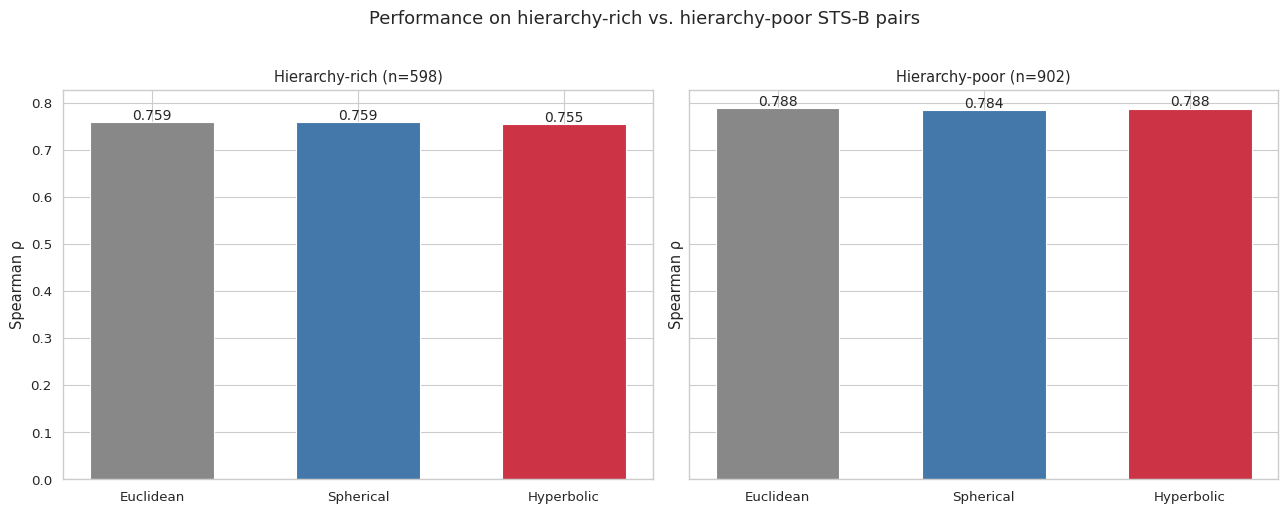

In [17]:
# ---- Visualize hierarchy-rich vs hierarchy-poor --------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

for ax, subset_name in zip(axes, ["Hierarchy-rich", "Hierarchy-poor"]):
    sub = subset_df[subset_df["Subset"] == subset_name]
    x = np.arange(len(sub))
    colors = ["#888888", "#4477AA", "#CC3344"]

    bars = ax.bar(x, sub["Spearman ρ"].values, color=colors, edgecolor="white", width=0.6)

    ax.set_xticks(x)
    ax.set_xticklabels(sub["Method"].values)
    ax.set_ylabel("Spearman ρ")
    ax.set_title(f"{subset_name} (n={sub['n'].values[0]})")

    for i, v in enumerate(sub["Spearman ρ"].values):
        ax.text(i, v + 0.005, f"{v:.3f}", ha="center", fontsize=10)

plt.suptitle("Performance on hierarchy-rich vs. hierarchy-poor STS-B pairs",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "hierarchy_subset_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

## 12. Summary and conclusions

Final comparison table and discussion of what the geometric analysis reveals about WMD for sentence similarity.

In [18]:
# ---- Final summary --------------------------------------------------------
print("=" * 60)
print(" FINAL RESULTS")
print("=" * 60)
print()

print("Main comparison (STS-B validation, 1500 pairs):")
print(results_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
print()

print("Hierarchy-rich vs. hierarchy-poor subset analysis:")
print(subset_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
print()

print("Configuration:")
print(f"  Embeddings:     GloVe 300d (raw)")
print(f"  Lemmatization:  WordNet")
print(f"  Weighting:      TF-IDF (IDF from STS-B train)")
print(f"  Transport:      Exact EMD (POT)")
print(f"  Calibration c:  {C_CALIBRATION:.4f} (mean GloVe norm)")

 FINAL RESULTS

Main comparison (STS-B validation, 1500 pairs):
         Method  Spearman ρ  Pearson r  Failed pairs
Cosine baseline      0.7389     0.7255             0
  Euclidean WMD      0.7768     0.7736             0
  Spherical WMD      0.7748     0.7728             0
 Hyperbolic WMD      0.7744     0.7697             0

Hierarchy-rich vs. hierarchy-poor subset analysis:
        Subset     Method  Spearman ρ  Pearson r   n
Hierarchy-rich  Euclidean      0.7589     0.7582 598
Hierarchy-rich  Spherical      0.7590     0.7592 598
Hierarchy-rich Hyperbolic      0.7547     0.7523 598
Hierarchy-poor  Euclidean      0.7882     0.7813 902
Hierarchy-poor  Spherical      0.7843     0.7789 902
Hierarchy-poor Hyperbolic      0.7876     0.7795 902

Configuration:
  Embeddings:     GloVe 300d (raw)
  Lemmatization:  WordNet
  Weighting:      TF-IDF (IDF from STS-B train)
  Transport:      Exact EMD (POT)
  Calibration c:  6.8640 (mean GloVe norm)


In [19]:
# ---- Bootstrap confidence intervals on Spearman ρ -----------------------
def bootstrap_spearman(scores, labels, n_boot=1000, seed=42):
    """Compute 95% CI for Spearman ρ via bootstrap resampling."""
    rng = np.random.RandomState(seed)
    n = len(scores)
    rhos = []
    for _ in range(n_boot):
        idx = rng.randint(0, n, size=n)
        rho, _ = spearmanr(scores[idx], labels[idx])
        rhos.append(rho)
    rhos = np.sort(rhos)
    return rhos[int(0.025 * n_boot)], rhos[int(0.975 * n_boot)]

print("Bootstrap 95% CIs on Spearman ρ (1000 resamples):\n")
for res in all_results:
    if res["label"] == "Cosine baseline":
        s = res["scores"]
    else:
        s = -res["scores"]
    lo, hi = bootstrap_spearman(s, res["labels"])
    print(f"  {res['label']:<20s}  ρ = {res['spearman']:.4f}  [{lo:.4f}, {hi:.4f}]")

Bootstrap 95% CIs on Spearman ρ (1000 resamples):

  Cosine baseline       ρ = 0.7389  [0.7128, 0.7635]
  Euclidean WMD         ρ = 0.7768  [0.7534, 0.7970]
  Spherical WMD         ρ = 0.7748  [0.7516, 0.7959]
  Hyperbolic WMD        ρ = 0.7744  [0.7508, 0.7955]


### Conclusions

**Contribution.** This notebook provides a controlled ablation isolating cost-function geometry as the sole experimental variable. The key finding is negative but informative: under identical preprocessing, weighting, and solver, the choice of c(i,j) — Euclidean, spherical, or hyperbolic — has negligible impact on WMD-based sentence similarity. This isolates the training signal, not the distance function, as the critical factor for geometry-aware sentence similarity.

**Overall comparison.** All three WMD geometries perform within 0.002 Spearman of each other on STS-B validation (Euclidean 0.777, Spherical 0.775, Hyperbolic 0.774), with overlapping 95% bootstrap confidence intervals confirming the difference is not statistically meaningful.

**Transport vs. averaging.** WMD consistently outperforms the cosine-of-mean baseline (0.739) by roughly +0.036 Spearman across all geometries. This confirms that word-level optimal transport captures alignment structure that simple averaging misses, justifying the computational cost of EMD.

**Hierarchy-rich subset.** No geometry gains an advantage on pairs with cross-sentence WordNet hypernymy relations (all three within 0.004 of each other). The exponential map projection preserves GloVe's neighborhood structure but does not introduce the hierarchical signal that natively trained Poincaré embeddings encode. This suggests that hyperbolic geometry's advantage for NLP requires training in hyperbolic space — not post-hoc projection of Euclidean vectors.

**Implications and next steps.** These results support a clear conclusion: the exponential map projection into hyperbolic space does not improve WMD-based sentence similarity over flat or spherical geometry when applied to Euclidean-trained embeddings. The bottleneck is the training signal, not the cost function. The HyperLex diagnostic notebook validates this claim on a word-level task — HyperLex with Poincaré embeddings natively trained on WordNet hypernymy pairs (Nickel & Kiela, 2017) — where hyperbolic geometry does yield measurable gains. The native hyperbolic WMD notebook then tests whether a general-vocabulary hyperbolic embedding (Tifrea Poincaré GloVe, 2019) can transfer those gains to STS-B.

### Limitations

- **Euclidean-trained embeddings.** GloVe vectors are trained with Euclidean objectives; the exponential map is a post-hoc approximation that cannot introduce geometric structure absent from training.
- **Benchmark bias.** STS-B is dominated by paraphrastic pairs with relatively flat semantic structure, limiting the opportunity for hyperbolic geometry to demonstrate advantages on hierarchical content.
- **Scalability.** Exact EMD via the POT solver is O(n³) in vocabulary overlap per pair, limiting applicability to short texts.
- **Single embedding model.** Results may differ with other pretrained embeddings (word2vec, fastText) or higher/lower dimensionality.

**Reproducibility.** All experiments can be reproduced by running cells in order. Figures and result tables are saved to `figures/wmd_geometric_comparison/`.